In [1]:
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!unzip /content/Bones-data.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

In [4]:
size = [224, 224] + [3]
size

[224, 224, 3]

In [6]:
train_path = './Bones-data/train'
valid_path = './Bones-data/test'

In [7]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
import numpy as np
from glob import glob
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten

In [8]:
vgg16 = VGG16(input_shape=IMAGE_SIZE + [3],  weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 101s 2us/step


In [11]:
for layer in vgg16.layers:
  print(layer.trainable)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


In [10]:
for layer in vgg16.layers:
    layer.trainable = False

In [12]:
for layer in vgg16.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [14]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
folders = glob('./Bones-data/train/*')
folders

['./Bones-data/train\\Oblique fracture', './Bones-data/train\\Spiral Fracture']

In [25]:
num_of_class = len(folders)
num_of_class

2

In [26]:
model = Sequential()
model.add(vgg16)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(num_of_class,activation='softmax'))

In [28]:
# view the structure of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [31]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [32]:
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 143 images belonging to 2 classes.


In [33]:
test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 28 images belonging to 2 classes.


In [34]:
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 71s 10s/step - accuracy: 0.5035 - loss: 6.1309 - val_accuracy: 0.5714 - val_loss: 2.3665
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.5594 - loss: 1.3084 - val_accuracy: 0.4286 - val_loss: 1.6467
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.5035 - loss: 0.9642 - val_accuracy: 0.5714 - val_loss: 0.9961
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 48s 9s/step - accuracy: 0.5804 - loss: 0.7009 - val_accuracy: 0.4286 - val_loss: 0.9886
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 7s/step - accuracy: 0.6224 - loss: 0.6750 - val_accuracy: 0.5000 - val_loss: 0.7480
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.7902 - loss: 0.5343 - val_accuracy: 0.5357 - val_loss: 0.7654
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 51s 10s/step - accuracy: 0.7902 - loss: 0.4984 - val_accuracy: 0.5714 - val_loss: 0.7177
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 10s/step - accuracy: 0.7832 - loss: 0.4642 - val_accuracy: 0.5357 - val_loss: 0.7143
Epoch

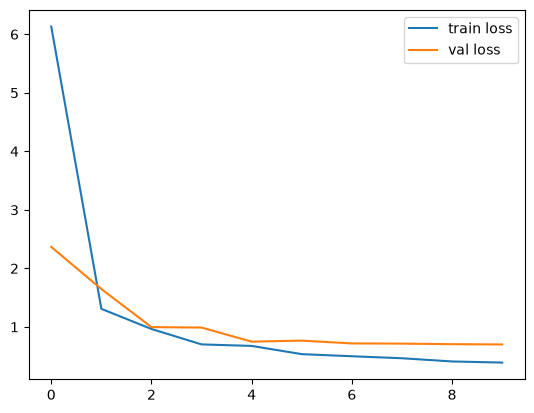

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

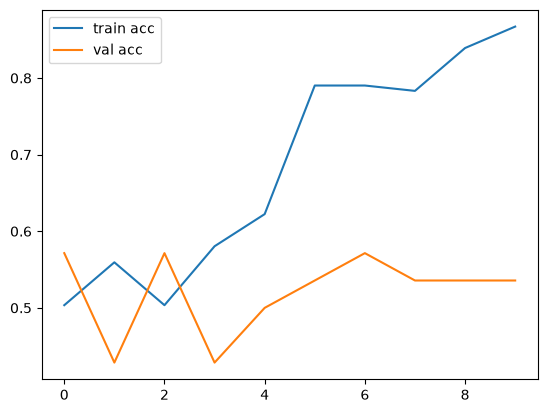

<Figure size 640x480 with 0 Axes>

In [36]:
# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [37]:
model.evaluate(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5357 - loss: 0.6999


[0.6998707056045532, 0.5357142686843872]

In [38]:
from tensorflow.keras.models import load_model

model.save('model_vgg16.h5')

In [39]:
model = load_model("model_vgg16.h5")

In [42]:
from tensorflow.keras.preprocessing import image

In [80]:
img = "./Bones-data/test/Spiral Fracture/0-_jumbo_jpeg.rf.7645898c0465d33bcd71ee0ddb847e0a.jpg"

In [81]:
img=image.load_img(img,target_size=(224,224))

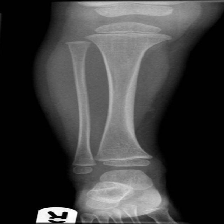

In [82]:
img

In [83]:
x=image.img_to_array(img)
x

array([[[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [85., 85., 85.],
        [85., 85., 85.],
        [85., 85., 85.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [87., 87., 87.],
        [86., 86., 86.],
        [84., 84., 84.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [48., 48., 48.],
        [46., 46., 46.],
        [44., 44., 44.]],

       ...,

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.]]

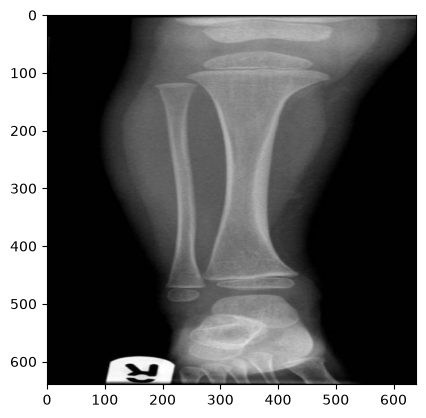

In [84]:
Z = plt.imread("./Bones-data/test/Spiral Fracture/0-_jumbo_jpeg.rf.7645898c0465d33bcd71ee0ddb847e0a.jpg")
plt.imshow(Z)

In [85]:
x.shape

(224, 224, 3)

In [86]:
x=x/255

In [87]:
from keras.applications.vgg16 import preprocess_input
import numpy as np
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)

In [88]:
img_data

array([[[[-103.93508 , -116.77508 , -123.67608 ],
         [-103.93508 , -116.77508 , -123.67608 ],
         [-103.93508 , -116.77508 , -123.67608 ],
         ...,
         [-103.60567 , -116.44566 , -123.346664],
         [-103.60567 , -116.44566 , -123.346664],
         [-103.60567 , -116.44566 , -123.346664]],

        [[-103.93508 , -116.77508 , -123.67608 ],
         [-103.93508 , -116.77508 , -123.67608 ],
         [-103.93508 , -116.77508 , -123.67608 ],
         ...,
         [-103.597824, -116.43782 , -123.33882 ],
         [-103.601746, -116.44174 , -123.34274 ],
         [-103.60959 , -116.449585, -123.350586]],

        [[-103.93508 , -116.77508 , -123.67608 ],
         [-103.93508 , -116.77508 , -123.67608 ],
         [-103.93508 , -116.77508 , -123.67608 ],
         ...,
         [-103.75077 , -116.59077 , -123.49177 ],
         [-103.75861 , -116.59861 , -123.49961 ],
         [-103.76646 , -116.60645 , -123.507454]],

        ...,

        [[-103.93508 , -116.77508 , -1

In [89]:
output = model.predict(img_data)
output

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


array([[0.10917548, 0.89082456]], dtype=float32)

In [90]:
result = np.argmax(output, axis=1)
result

array([1])

In [91]:
if result[0] == 0:
    prediction = 'Oblique fracture'
    print(prediction)
else:
    prediction = 'Spiral Fracture'
    print(prediction)

Spiral Fracture
